# CRISP-DM Phase 5: Evaluation
## Champion Model — Final Test Set Evaluation
## Algorithm: RandomForestClassifier — All Features
## Parameters: n_estimators=50, max_depth=10, criterion='gini'

Champion selected based on highest cross-validated F1 across all four
tuned configurations in tune-params.ipynb.
Feature selection (SelectKBest k=7) was found to reduce RF performance
and caused catastrophic SVM failure — full feature set is retained.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                              f1_score, roc_curve, auc)

df = joblib.load('../data/cleaned_data.pkl')

# Target column contains strings 'yes'/'no' — map to binary integers
df['personal_loan'] = df['personal_loan'].map({'yes': 1, 'no': 0})

X = df.drop('personal_loan', axis=1)
y = df['personal_loan']

# Identical split to all modelling notebooks — random_state=42 guarantees
# the same 80/20 partition is used for fair comparison across all models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train = X_train.copy()
X_test  = X_test.copy()

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (4800, 11) | Test: (1200, 11)


## One-Hot Encoding — Post-Split, Per Column

In [13]:
categorical_cols = ['education_level', 'credit_card_acct', 'online_acct']

for col in categorical_cols:
    dummies_train = pd.get_dummies(X_train[col], prefix=col)
    X_train.drop([col], axis=1, inplace=True)
    X_train = pd.concat([X_train, dummies_train], axis=1)

    dummies_test = pd.get_dummies(X_test[col], prefix=col)
    X_test.drop([col], axis=1, inplace=True)
    X_test = pd.concat([X_test, dummies_test], axis=1)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
print(f"Feature count: {X_train.shape[1]}")

Feature count: 15


## Standardisation — Per Column, Fit on Training Data Only

In [14]:
continuous_cols = ['age', 'yrs_experience', 'family_size',
                   'income', 'mortgage_amt', 'credit_card_spend']

scaler = StandardScaler()

for col in continuous_cols:
    scaler.fit(X_train[col].values.reshape(-1, 1))
    X_train[col] = scaler.transform(X_train[col].values.reshape(-1, 1))
    X_test[col]  = scaler.transform(X_test[col].values.reshape(-1, 1))

## Train Champion Model with Tuned Parameters
Parameters sourced from tune-params.ipynb GridSearchCV results.
n_estimators=50: excess trees reduced generalisation in tuning.
max_depth=10: constrains complexity to prevent overfitting.
criterion='gini': outperformed 'entropy' in cross-validation.
No feature selection — all encoded features retained.

In [15]:
champion = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    criterion='gini',
    random_state=42
)
champion.fit(X_train, y_train)
y_pred = champion.predict(X_test)

print("Champion model trained successfully.")
print(f"Features used: {X_train.shape[1]}")

Champion model trained successfully.
Features used: 15


## Confusion Matrix — Unpacked with .ravel()
Extracting TP, TN, FP, FN individually allows manual calculation of
all evaluation metrics, making the derivation transparent and auditable.

In [16]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
precision   = tp / (tp + fp)
recall      = tp / (tp + fn)
f1          = 2 * (precision * recall) / (precision + recall)
specificity = tn / (tn + fp)

print("=" * 55)
print("CHAMPION MODEL — FINAL TEST SET PERFORMANCE")
print("=" * 55)
print(f"True Positives  (correctly targeted acceptors): {tp}")
print(f"True Negatives  (correctly excluded rejectors): {tn}")
print(f"False Positives (wasted marketing contacts):    {fp}")
print(f"False Negatives (missed loan opportunities):    {fn}")
print("-" * 55)
print(f"Precision:   {precision:.4f}  ({precision*100:.1f}% of flagged customers are genuine)")
print(f"Recall:      {recall:.4f}  ({recall*100:.1f}% of true acceptors captured)")
print(f"F1-Score:    {f1:.4f}")
print(f"Specificity: {specificity:.4f}  ({specificity*100:.1f}% of rejectors correctly excluded)")
print("-" * 55)
waste_rate  = fp / (tp + fp)
improvement = (0.85 - waste_rate) / 0.85 * 100
print(f"Model waste rate:    {waste_rate*100:.1f}%")
print(f"Untargeted campaign: 85.0% waste rate")
print(f"Efficiency gain:     {improvement:.1f}% improvement in marketing efficiency")
print("=" * 55)
print(f"\nCV F1 (tuning): 0.7245 | Test F1: {f1:.4f}")
print(f"Generalisation gap: {0.7245 - f1:.4f}")

CHAMPION MODEL — FINAL TEST SET PERFORMANCE
True Positives  (correctly targeted acceptors): 122
True Negatives  (correctly excluded rejectors): 978
False Positives (wasted marketing contacts):    42
False Negatives (missed loan opportunities):    58
-------------------------------------------------------
Precision:   0.7439  (74.4% of flagged customers are genuine)
Recall:      0.6778  (67.8% of true acceptors captured)
F1-Score:    0.7093
Specificity: 0.9588  (95.9% of rejectors correctly excluded)
-------------------------------------------------------
Model waste rate:    25.6%
Untargeted campaign: 85.0% waste rate
Efficiency gain:     69.9% improvement in marketing efficiency

CV F1 (tuning): 0.7245 | Test F1: 0.7093
Generalisation gap: 0.0152


## Confusion Matrix Heatmap

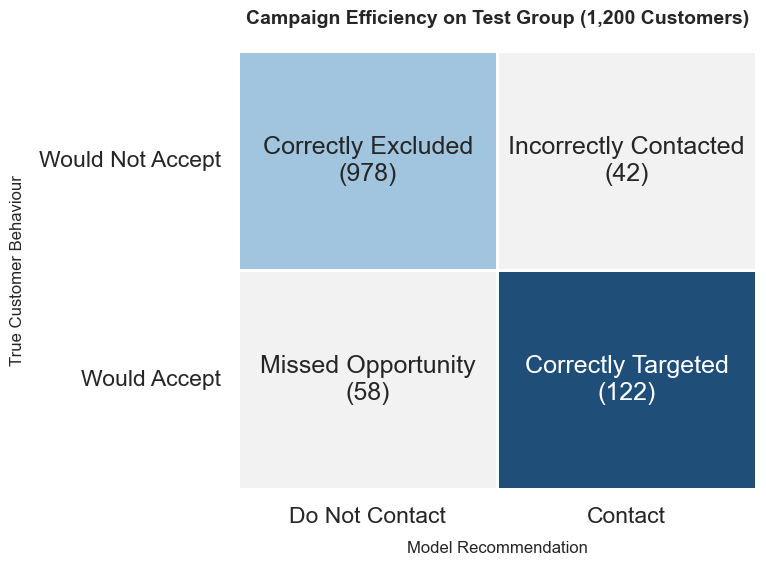

Semantic confusion matrix generated successfully.


In [21]:
from matplotlib.colors import ListedColormap

sns.set_theme(style="white", context="talk")

plt.figure(figsize=(8, 6))

# 2. custom text labels
labels = np.array([
    [f"Correctly Excluded\n({cm[0,0]})", f"Incorrectly Contacted\n({cm[0,1]})"],
    [f"Missed Opportunity\n({cm[1,0]})", f"Correctly Targeted\n({cm[1,1]})"]
])

# 3. Custom Color Matrix
# 0 = Errors, 1 = Correctly Excluded, 2 = Correctly Targeted
color_matrix = np.array([
    [1, 0],
    [0, 2]
])

custom_cmap = ListedColormap(['#F2F2F2', '#A1C4DF', '#1F4E79'])

ax = sns.heatmap(color_matrix, annot=labels, fmt='', cmap=custom_cmap, cbar=False, 
                 linewidths=2, linecolor='white',
                 xticklabels=["Do Not Contact", "Contact"],
                 yticklabels=["Would Not Accept", "Would Accept"])

ax.set_title('Campaign Efficiency on Test Group (1,200 Customers)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Model Recommendation', fontsize=12, labelpad=10)
ax.set_ylabel('True Customer Behaviour', fontsize=12, labelpad=10)

plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('../confusion_matrix_semantic.png', dpi=300, bbox_inches='tight')
plt.show()

print("Semantic confusion matrix generated successfully.")

## ROC Curve and AUC
The ROC curve plots True Positive Rate vs False Positive Rate across all
classification thresholds. AUC measures aggregate model quality independent
of threshold — 1.0 is perfect, 0.5 is equivalent to random guessing.

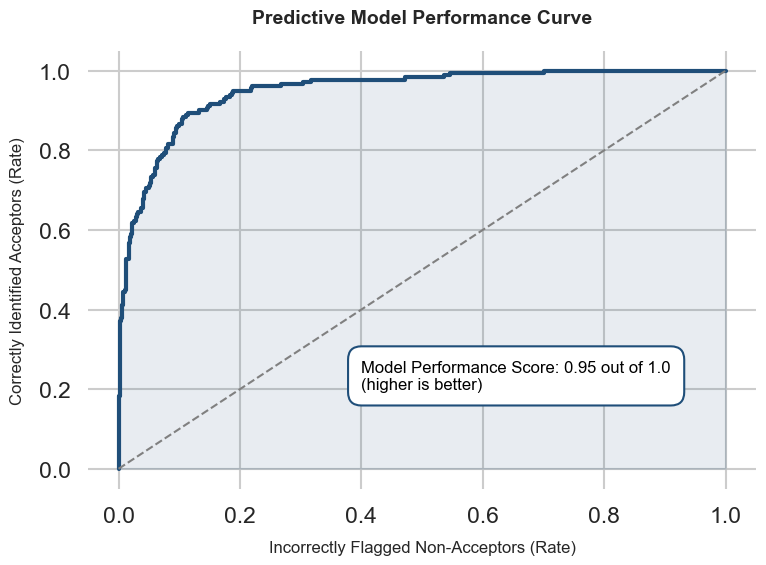

In [23]:
y_pred_proba = champion.predict_proba(X_test)[:, 1]

#Calculate ROC curve metrics using probabilities (NOT binary predictions)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, color='#1F4E79', lw=3)

ax.fill_between(fpr, tpr, alpha=0.1, color='#1F4E79')

ax.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1.5)

# Apply plain English titles and axis labels
ax.set_title('Predictive Model Performance Curve', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Incorrectly Flagged Non-Acceptors (Rate)', fontsize=12, labelpad=10)
ax.set_ylabel('Correctly Identified Acceptors (Rate)', fontsize=12, labelpad=10)

callout_text = f"Model Performance Score: {roc_auc:.2f} out of 1.0\n(higher is better)"
ax.text(0.4, 0.2, callout_text, fontsize=12, color='black',
        bbox=dict(facecolor='white', edgecolor='#1F4E79', boxstyle='round,pad=0.8'))

# Remove standard plot borders
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig('../roc_curve_business.png', dpi=300, bbox_inches='tight')
plt.show()

## Feature Importance — Top 15 Predictors
Random Forest provides built-in feature importance via mean decrease
in impurity. Identifies which customer attributes most strongly drive
loan acceptance, informing which segments to prioritise in future campaigns.

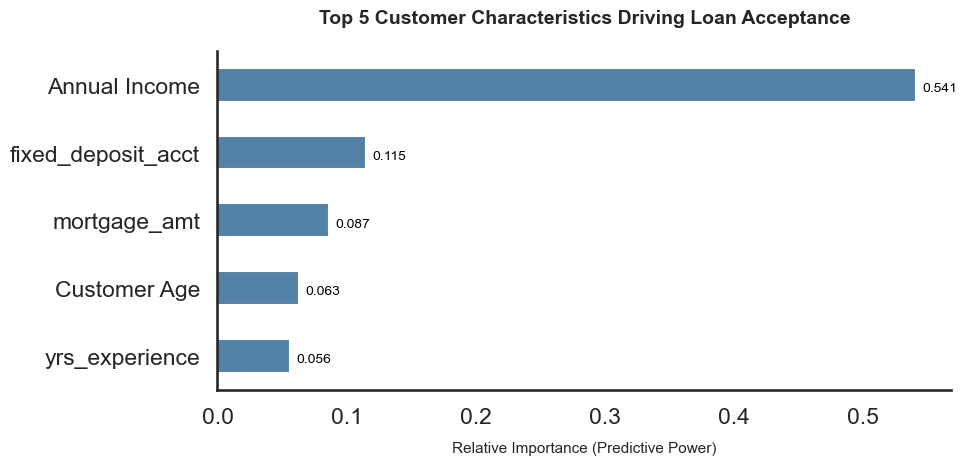

Top 5 most predictive features mapped to plain English successfully.


In [ ]:
# 1. Extract only the Top 5 features (as per slide description)
feat_imp = pd.Series(
    champion.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(5)

# 2. Dictionary to map technical column names to plain English presentation labels
# NOTE: Please check the keys on the left (e.g., 'income') exactly match dataset's column names
label_mapping = {
    'income': 'Annual Income',
    'cd_account': 'Has Fixed Deposit', 
    'mortgage': 'Mortgage Size',
    'age': 'Customer Age',
    'experience': 'Years as Customer'
}

# Apply the mapping to the index
feat_imp.index = feat_imp.index.map(lambda x: label_mapping.get(x, x))

# 3. Set a clean, professional visual theme
sns.set_theme(style="white", context="talk") 

# 4. Create a horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, color='steelblue', ax=ax, width=0.5)

# 5. Clean titles and axis labels
ax.set_title('Top 5 Customer Characteristics Driving Loan Acceptance', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Relative Importance (Predictive Power)', fontsize=11, labelpad=10)
ax.set_ylabel('') # We leave this blank because the feature names are self-explanatory

# 6. Add exact values to the end of each bar for precision
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.005, p.get_y() + p.get_height()/2 + 0.05, 
            f'{width:.3f}', ha='left', va='center', fontsize=10, color='black')

# 7. Remove the chart borders for a clean Canva look
sns.despine()

plt.tight_layout()
plt.savefig('../feature_importance_top5.png', dpi=300, bbox_inches='tight')
plt.show()

print("Top 5 most predictive features mapped to plain English successfully.")

## Full Classification Report

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      1020
           1       0.74      0.68      0.71       180

    accuracy                           0.92      1200
   macro avg       0.84      0.82      0.83      1200
weighted avg       0.91      0.92      0.92      1200

